# EDA

## Importing libaries

In [18]:
%pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import re
from matplotlib import pyplot as plt
import string
import nltk
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
from nltk.util import ngrams
import warnings

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Loading Input datasets

Both datasets are collected from Kaggle. First we will perform EDA step.

In [68]:
enron_dataset = pd.read_csv('./data/raw/enron_spam_data.csv')

## Data Overview
- Check number of sample
- Check number of feature
- Check data type
- Check label imbalance

In [4]:
enron_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Message ID  33716 non-null  int64
 1   Subject     33427 non-null  str  
 2   Message     33345 non-null  str  
 3   Spam/Ham    33716 non-null  str  
 4   Date        33716 non-null  str  
dtypes: int64(1), str(4)
memory usage: 1.3 MB


-> Có 33716 sample trong raw dataset

-> Có 5 feature trong raw dataset

Tất cả các feature đều có type là str ngoại trừ Message ID là int64

Khi quan sát số lượng Non-Null ở cột Subject, Message, ta sẽ thấy số lượng hao hụt ít hơn so với tổng số lượng sample, chứng tỏ dữ liệu đang bị khuyết thiếu

In [5]:
enron_dataset.value_counts(enron_dataset['Spam/Ham'])

Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64

## Plotting class distribution using Bar chart

Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64


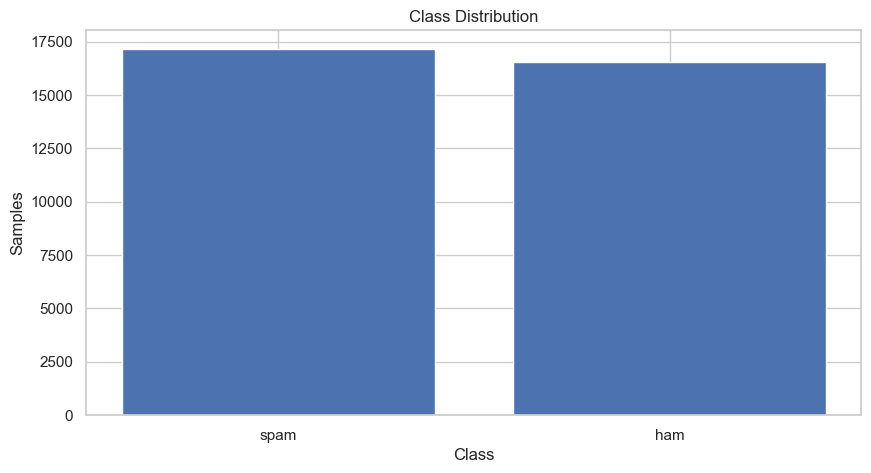

In [6]:
# Plotting bar chart, using Matplotlib library
colors = sns.color_palette(palette='bright')
# Counting the frequency of SPAM/HAM labels to visualize the bar chart
label_counts = enron_dataset['Spam/Ham'].value_counts()
labels = ['spam','ham']

print(label_counts)

# Setting figure size
plt.figure(figsize=(10, 5))

# Creating bar chart
plt.bar(labels, label_counts)

# Adding title and labels
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Samples")

plt.show()

## Missing Data Analysis
Mục tiêu: Phát hiện, phân tích quy luật và xử lý các ô dữ liệu bị trống (NaN) một cách có chủ đích

- Detect các missing values
- Tính tỷ lệ missing theo từng feature một:
    - Nếu feature Message bị null thì drop luôn vì nội dung email mà không có thì không có giá trị gì cả
    - Nếu feature Subject bị null thì không cần drop mà Impute "No Subject" vào
- Thống kê số lượng email bị khuyết cả Subject lẫn Message
- Lọc ra toàn bộ các email bị missing cột Subject. Sau đó đếm xem trong tập bị missing này, tỷ lệ Spam/Ham là bao nhiêu?
- Tính tỷ lệ thiếu Subject tại các nhãn Spam/Ham
- Tính tỷ lệ các email có viết hoa tại Subject tại Spam/Ham
- Tính tỷ lệ lạm dụng các ký tự đặc biệt ở Subject tại Spam/Ham


In [7]:
missing_count = enron_dataset.isnull().sum()
missing_pct = (enron_dataset.isnull().sum() / len(enron_dataset)) * 100

missing_df = pd.DataFrame({
    'Số lượng Missing': missing_count,
    'Tỷ lệ Missing (%)': missing_pct
})
print(missing_df[missing_df['Số lượng Missing'] > 0])

         Số lượng Missing  Tỷ lệ Missing (%)
Subject               289           0.857160
Message               371           1.100368


In [9]:
warnings.filterwarnings('ignore')

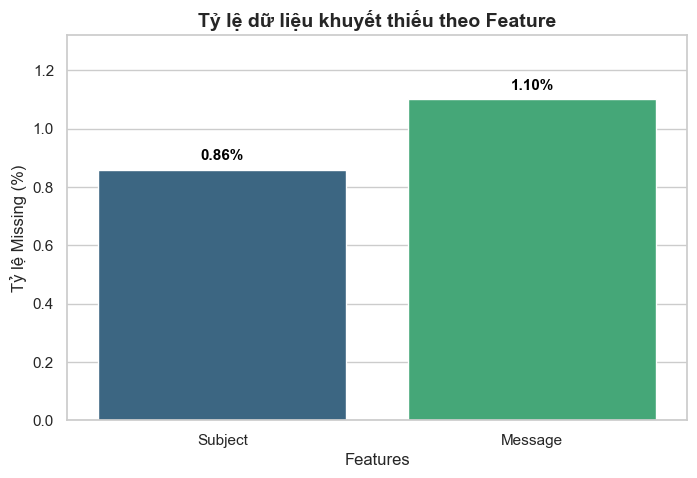

In [10]:
missing_features = missing_pct[missing_pct > 0]
if not missing_features.empty:
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x=missing_features.index, y=missing_features.values, palette="viridis")
    plt.title('Tỷ lệ dữ liệu khuyết thiếu theo Feature', fontsize=14, fontweight='bold')
    plt.ylabel('Tỷ lệ Missing (%)', fontsize=12)
    plt.xlabel('Features', fontsize=12)
    plt.ylim(0, max(missing_features.values) * 1.2)
    
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')
    plt.show()

-> Tập dữ liệu thu thập ban đầu tương đối tốt
- Cột Message bị thiếu 371 sample
- Cột Subject bị thiếu 289 sample

In [69]:
ghost_emails_df = enron_dataset[enron_dataset['Subject'].isnull() & enron_dataset['Message'].isnull()]

In [70]:
len(ghost_emails_df)

51

-> Phát hiện 289 email bị thiếu Subject


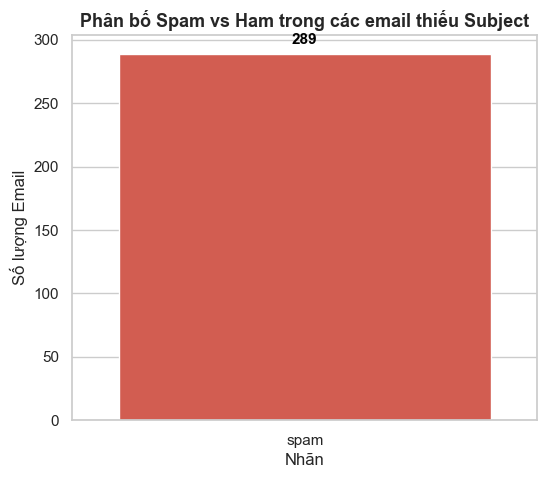

In [13]:
missing_subject_df = enron_dataset[enron_dataset['Subject'].isnull()]

if not missing_subject_df.empty:
    print(f"-> Phát hiện {len(missing_subject_df)} email bị thiếu Subject")
    
    plt.figure(figsize=(6, 5))
    ax2 = sns.countplot(data=missing_subject_df, x='Spam/Ham', palette={'ham': '#2ecc71', 'spam': '#e74c3c'},legend=False)
    plt.title('Phân bố Spam vs Ham trong các email thiếu Subject', fontsize=13, fontweight='bold')
    plt.ylabel('Số lượng Email', fontsize=12)
    plt.xlabel('Nhãn', fontsize=12)
    
    for p in ax2.patches:
        ax2.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')
    plt.show()

Khi phân tích sâu vào 289 email bị thiếu Subject, biểu đồ phân bố cho thấy là 100% (289/289) email không có tiêu đề đều là thư rác (Spam) Không có bất kỳ một email công việc thật (Ham) nào quên ghi tiêu đề vì có thể trong môi trường công sở chuyên nghiệp (bối cảnh của tập dữ liệu Enron), nhân viên luôn tuân thủ nguyên tắc viết email phải có tiêu đề rõ ràng để trao đổi công việc. Ngược lại những kẻ lừa đảo thường sử dụng các công cụ tự động (bots) để gửi thư rác hàng loạt và chúng thường lười điền tiêu đề, hoặc cố tình để trống nhằm kích thích sự tò mò, ép người dùng phải click vào mở email để xem nội dung

Từ insight trên, nhóm quyết định thực hiện xử lý riêng từng cột feature như sau:
- Đối với cột Message: Bắt buộc drop toàn bộ 371 email này vì 1 sample dữ liệu không có nội dung văn bản thì hoàn toàn vô giá trị, nếu giữ lại sẽ tạo thành noise làm giảm độ chính xác của model
- Đối với cột Subject: Không xóa, mà thực hiện điền khuyết bằng chuỗi văn bản cố định: "No Subject" vì việc "thiếu tiêu đề" đã được chứng minh là một hành vi đặc trưng của Spam. Khi điền chuỗi "No Subject", thuật toán TF-IDF ở bước sau sẽ đếm và gán trọng số rất cao cho cụm từ này. Qua đó, model sẽ tự động đúc kết được quy luật: "Cứ thấy email nào có chữ 'No Subject' thì xác suất cao là Spam"

In [71]:
initial_rows = len(enron_dataset)

enron_dataset = enron_dataset.dropna(subset=['Message'])
print(f"[-] Đã xóa {initial_rows - len(enron_dataset)} dòng bị thiếu 'Message' (Bao gồm toàn bộ Ghost Emails)")

enron_dataset.loc[:, 'Subject'] = enron_dataset['Subject'].fillna('No Subject')
print("[+] Đã điền chuỗi 'No Subject' cho các email bị thiếu 'Subject'")

[-] Đã xóa 371 dòng bị thiếu 'Message' (Bao gồm toàn bộ Ghost Emails)
[+] Đã điền chuỗi 'No Subject' cho các email bị thiếu 'Subject'


In [15]:
print(enron_dataset.isnull().sum())
enron_dataset.shape

Message ID    0
Subject       0
Message       0
Spam/Ham      0
Date          0
dtype: int64


(33345, 5)

In [16]:
no_subject_df = enron_dataset[enron_dataset['Subject'] == 'No Subject']
no_subject_counts = no_subject_df['Spam/Ham'].value_counts()

In [17]:
# Tính tỷ lệ % 'No Subject' trong nội bộ từng nhãn
total_spam = len(enron_dataset[enron_dataset['Spam/Ham'] == 'spam'])
total_ham = len(enron_dataset[enron_dataset['Spam/Ham'] == 'ham'])

In [72]:
spam_no_subj_rate = (no_subject_counts.get('spam', 0) / total_spam) * 100 if total_spam > 0 else 0
ham_no_subj_rate = (no_subject_counts.get('ham', 0) / total_ham) * 100 if total_ham > 0 else 0

rate_df = pd.DataFrame({
    'Nhãn': ['Spam', 'Ham'],
    'Tỷ lệ email không có Tiêu đề (%)': [spam_no_subj_rate, ham_no_subj_rate]
})

In [73]:
def uppercase_ratio(text):
    if text == 'No Subject' or pd.isna(text): 
        return 0
    text_str = str(text)
    letters = sum(1 for c in text_str if c.isalpha())
    if letters == 0: 
        return 0
    uppers = sum(1 for c in text_str if c.isupper())
    return uppers / letters

In [74]:
def suspicious_symbol_count(text):
    if text == 'No Subject' or pd.isna(text): 
        return 0
    return len(re.findall(r'[!?$%*]', str(text)))

In [75]:
enron_dataset['Subject_Upper_Ratio'] = enron_dataset['Subject'].apply(uppercase_ratio)
enron_dataset['Subject_Suspicious_Symbols'] = enron_dataset['Subject'].apply(suspicious_symbol_count)

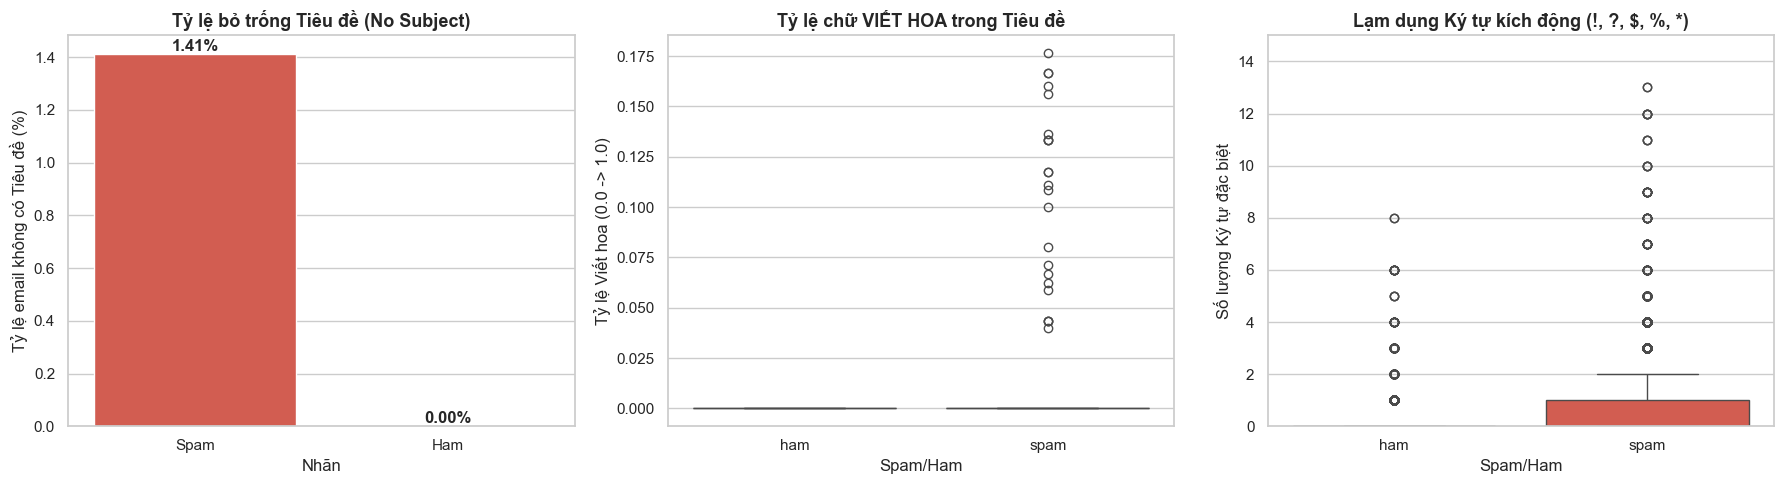

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=rate_df, x='Nhãn', y='Tỷ lệ email không có Tiêu đề (%)', palette={'Ham': '#2ecc71', 'Spam': '#e74c3c'}, ax=axes[0])
axes[0].set_title('Tỷ lệ bỏ trống Tiêu đề (No Subject)', fontsize=13, fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontweight='bold')

sns.boxplot(data=enron_dataset[enron_dataset['Subject'] != 'No Subject'], 
            x='Spam/Ham', y='Subject_Upper_Ratio', palette={'ham': '#2ecc71', 'spam': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Tỷ lệ chữ VIẾT HOA trong Tiêu đề', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Tỷ lệ Viết hoa (0.0 -> 1.0)')

sns.boxplot(data=enron_dataset[enron_dataset['Subject'] != 'No Subject'], 
            x='Spam/Ham', y='Subject_Suspicious_Symbols', palette={'ham': '#2ecc71', 'spam': '#e74c3c'}, ax=axes[2])
axes[2].set_title('Lạm dụng Ký tự kích động (!, ?, $, %, *)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Số lượng Ký tự đặc biệt')
axes[2].set_ylim(0, 15)

plt.tight_layout()
plt.show()

- Tỷ lệ bỏ trống tiêu đề ở lớp Spam là 1.41%, trong khi ở lớp Ham là 0.00% tuyệt đối. Nhân viên tập đoàn Enron tuân thủ quy tắc giao tiếp công sở rất nghiêm ngặt, 100% email đều có tiêu đề. Ngược lại, một bộ phận thư rác (Spam) được gửi đi từ các bot tự động hoặc những kẻ lừa đảo lười biếng đã bỏ trống phần này
- Biểu đồ Boxplot cho thấy Ham không có bất kỳ giá trị ngoại lai (outliers) nào, nghĩa là nhân viên viết hoa rất chuẩn mực. Trong khi đó, Spam xuất hiện một loạt các chấm ngoại lai với tỷ lệ viết hoa vọt lên từ 2.5% đến 17.5% cho thấy kẻ lừa đảo, thường xuyên sử dụng phím CAPS LOCK để tạo ra các tiêu đề la hét, gây chú ý mạnh (ví dụ: "URGENT", "FREE MONEY"). Sự vô kỷ luật trong ngữ pháp này là một dấu hiệu nhận diện Spam cực mạnh
- Thư Ham thỉnh thoảng có sử dụng ký tự đặc biệt (từ 1 đến 8 dấu) phục vụ cho công việc (ví dụ dấu ? để hỏi, dấu $ để báo giá). Tuy nhiên, phần thân hộp (Box) của Spam nhô cao hơn hẳn, với các đuôi ngoại lai kéo dài từ 3 đến hơn 12 ký tự

In [77]:
enron_dataset.drop(columns=['Subject_Upper_Ratio', 'Subject_Suspicious_Symbols'], inplace=True)

## Univariate Analysis
Mục tiêu: Khám phá đặc điểm phân bố của từng biến số một cách độc lập trên toàn bộ tập dữ liệu
- Biến đổi văn bản thô thành các con số có thể đo lường được bằng cách tạo 2 cột mới: Message_Length (Độ dài email) và Punct_Count (Số lượng dấu câu)
- Vẽ biểu đồ Histogram để xem phần lớn email có độ dài nằm trong khoảng nào
- Vẽ biểu đồ phân bố dấu câu
- Trực quan hóa 10 ký tự đặc biệt được sử dụng nhiều nhất trong toàn bộ tập dữ liệu để xem có sự lạm dụng các ký tự như !, $, * hay không
- Dùng kỹ thuật đếm từ để trực quan hóa Top 20 từ vựng xuất hiện nhiều nhất
- Vẽ Word Cloud tổng quát

In [78]:
warnings.filterwarnings('ignore')

In [79]:
# Đếm số lượng từ trong mỗi email (dựa vào khoảng trắng)
enron_dataset['Message_Length'] = enron_dataset['Message'].apply(lambda x: len(str(x).split()))

In [80]:
# Đếm tổng số lượng dấu câu trong mỗi email
enron_dataset['Punct_Count'] = enron_dataset['Message'].apply(lambda x: sum([1 for char in str(x) if char in string.punctuation]))

In [81]:
enron_dataset[['Message_Length', 'Punct_Count']].describe()

,Message_Length,Punct_Count
count,33345.000000,33345.000000
mean,306.772170,68.987674
std,855.622403,174.123274
min,1.000000,0.000000
25%,67.000000,12.000000
50%,148.000000,30.000000
75%,326.000000,77.000000
max,45448.000000,8313.000000


Dựa vào kết quả thống kê cơ bản trên đối với 33.345 email, nhóm rút ra insight như sau:
- Độ dài email có mean xấp xỉ 306.7 từ lớn hơn gấp đôi so với trung vị (Median / 50% = 148 từ). Đặc biệt, 75% số email có độ dài chỉ từ 326 từ trở xuống
- Số lượng dấu câu có mean xấp xỉ 68.9 dấu câu, lớn hơn gấp đôi trung vị là 30. 75% email sử dụng ít hơn 77 dấu câu

-> Vậy hầu hết các email đều tương đối ngắn gọn (phản ánh đúng đặc thù trao đổi công việc hoặc các tin nhắn rác giật tít). Sự chênh lệch khổng lồ giữa Mean và Median báo hiệu biểu đồ Histogram sẽ có một cái đuôi kéo rất dài về bên phải

- Mặc dù 75% email chỉ dài tối đa 326 từ, nhưng Max lại lên tới 45.448 từ (một con số lớn) và chứa đến 8.313 dấu câu. Độ lệch chuẩn lên tới 855.6 cho thấy sự phân tán dữ liệu là cực kỳ lớn, những con số 45.448 từ này chắc chắn là dữ liệu dị biệt (có thể là file nhật ký hệ thống - log files, một chuỗi email forward đính kèm văn bản dài, hoặc các mã HTML rác, ....)

- Min của độ dài email là 1 từ, và min của số lượng dấu câu là 0. Khi mà một email chỉ có đúng 1 chữ gần như không mang lại ngữ cảnh để thuật toán phân loại hiểu được đó là Spam hay Ham

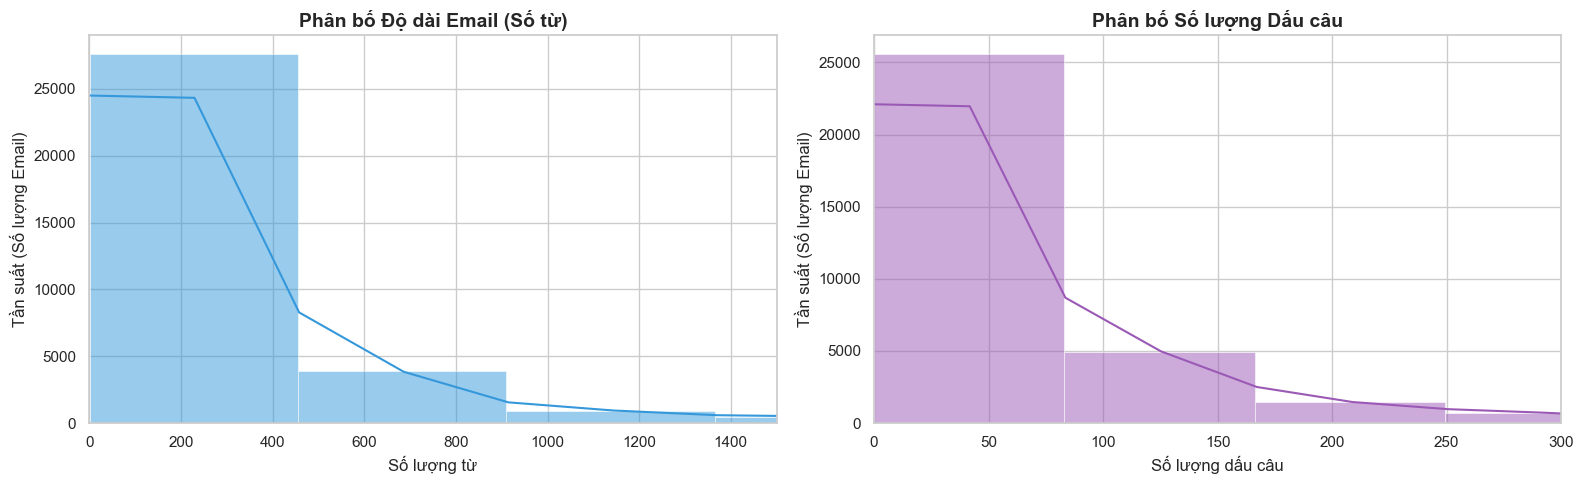

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(enron_dataset['Message_Length'], bins=100, kde=True, color='#3498db', ax=axes[0])
axes[0].set_title('Phân bố Độ dài Email (Số từ)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số lượng từ')
axes[0].set_ylabel('Tần suất (Số lượng Email)')
axes[0].set_xlim(0, 1500)

sns.histplot(enron_dataset['Punct_Count'], bins=100, kde=True, color='#9b59b6', ax=axes[1])
axes[1].set_title('Phân bố Số lượng Dấu câu', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Số lượng dấu câu')
axes[1].set_ylabel('Tần suất (Số lượng Email)')
axes[1].set_xlim(0, 300)

plt.tight_layout()
plt.show()

-> Qua hai biểu đồ Histogram về độ dài email và số lượng dấu câu, chúng ta có thể quan sát rõ rệt hiện tượng phân bố lệch phải của toàn bộ tập dữ liệu. Khối lượng dữ liệu tập trung dày đặc ở khu vực có giá trị thấp, cho thấy hầu hết các email đều rất ngắn (dưới 250 từ và sử dụng ít hơn 50 dấu câu), phản ánh chính xác thói quen giao tiếp súc tích trong môi trường công sở cũng như đặc thù giật tít nhanh của các email lừa đảo. Tuy nhiên, đường cong phân bố (KDE) cũng làm nổi bật một phần đồ thị mỏng kéo rất dài về phía bên phải, đại diện trực quan cho nhóm dữ liệu outliers mang giá trị lớn bất thường mà chúng ta đã phát hiện trong bảng thống kê mô tả trước đó. Từ minh chứng trực quan này, nhóm có cơ sở thực tiễn vững chắc để quyết định áp dụng phương pháp toán học IQR trong bước tiếp theo nhằm loại bỏ phần đuôi dài này. Việc chủ động loại bỏ các email dài lê thê hoặc chứa lượng dấu câu đột biến sẽ giúp thu gọn không gian ma trận từ vựng (TF-IDF), tối ưu hóa bộ nhớ RAM và tăng cường tốc độ train cho model mà không làm biến dạng cấu trúc gốc của dữ liệu

In [83]:
# Gộp toàn bộ văn bản để đếm ký tự đặc biệt
all_text = " ".join(enron_dataset['Message'].astype(str))
all_punct = [char for char in all_text if char in string.punctuation]

In [84]:
# Đếm và lấy Top 10
top_punct = Counter(all_punct).most_common(10)
df_punct = pd.DataFrame(top_punct, columns=['Ký tự', 'Tần suất'])

In [85]:
for index, row in df_punct.iterrows():
    print(f"  Top {index + 1}: Ký tự [ {row['Ký tự']} ] - Xuất hiện: {row['Tần suất']:,} lần")

  Top 1: Ký tự [ . ] - Xuất hiện: 515,625 lần
  Top 2: Ký tự [ - ] - Xuất hiện: 400,743 lần
  Top 3: Ký tự [ , ] - Xuất hiện: 379,411 lần
  Top 4: Ký tự [ / ] - Xuất hiện: 169,062 lần
  Top 5: Ký tự [ : ] - Xuất hiện: 158,626 lần
  Top 6: Ký tự [ ' ] - Xuất hiện: 78,266 lần
  Top 7: Ký tự [ _ ] - Xuất hiện: 68,307 lần
  Top 8: Ký tự [ ) ] - Xuất hiện: 55,469 lần
  Top 9: Ký tự [ ? ] - Xuất hiện: 54,844 lần
  Top 10: Ký tự [ ( ] - Xuất hiện: 52,240 lần


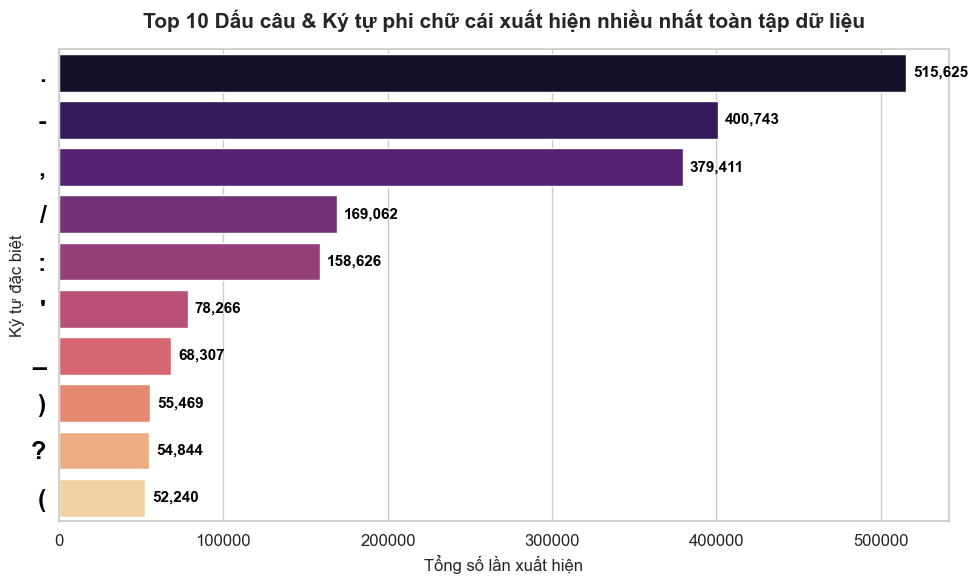

In [86]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Tần suất', y='Ký tự', data=df_punct, palette='magma')

plt.yticks(fontsize=18, fontweight='bold', color='black')
plt.xticks(fontsize=12)

plt.title('Top 10 Dấu câu & Ký tự phi chữ cái xuất hiện nhiều nhất toàn tập dữ liệu', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Tổng số lần xuất hiện', fontsize=12)
plt.ylabel('Ký tự đặc biệt', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                fontsize=11, fontweight='bold', color='black', 
                xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

Dựa trên bảng thống kê Top 10 ký tự đặc biệt xuất hiện nhiều nhất trên tập dữ liệu, nhóm rút ra các insight sau:
- Các dấu chấm (.) và phẩy (,) dẫn đầu là điều hiển nhiên trong văn phong tiếng Anh thông thường. Tuy nhiên, dấu gạch ngang (-) lại chễm chệ ở Top 2 với hơn 400.000 lần xuất hiện. Khác với văn bản văn học, email thường chứa rất nhiều dải phân cách (ví dụ: ----- Original Message -----), chữ ký tự động (signatures), hoặc gạch đầu dòng báo cáo công việc.
- Sự kết hợp của dấu hai chấm (: ở vị trí Top 5) và dấu gạch chéo (/ ở vị trí Top 4) là minh chứng cho sự tồn tại của một lượng khổng lồ các đường link website (cấu trúc http://... hoặc https://...)
- Dấu gạch dưới (_ ở Top 7) là một ký tự cực kỳ hiếm gặp trong văn bản thường, nhưng lại là thành phần "quốc dân" trong các địa chỉ email (ví dụ: john_doe@...) hoặc tên file đính kèm
- Đáng chú ý nhất là sự biến mất hoàn toàn của dấu chấm than (!) và ký hiệu tiền tệ ($) khỏi Top 10. Theo trực giác, đây là 2 vũ khí tối thượng của thư rác (dùng để giật tít và chào mời tài chính). Sự vắng mặt này là do chúng ta đang phân tích gộp toàn bộ tập dữ liệu. Khối lượng email trao đổi công việc nội bộ (Ham) chuẩn mực của tập đoàn Enron đã làm loãng hoàn toàn các ký tự rác này

In [87]:
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

In [88]:
all_text = " ".join(enron_dataset['Message'].astype(str))
words = re.findall(r'\b[A-Za-z]+\b', all_text.lower())
clean_words = [word for word in words if word not in stop_words]
word_counts = Counter(clean_words)
top_20 = word_counts.most_common(20)
df_words = pd.DataFrame(top_20, columns=['Từ vựng', 'Tần suất'])

In [89]:
top_20_words_list = df_words['Từ vựng'].tolist()
print(top_20_words_list)

['enron', 'ect', 'com', 'company', 'please', 'hou', 'e', 'would', 'new', 'subject', 'may', 'information', 'time', 'said', 'business', 'one', 'gas', 'us', 'energy', 'http']


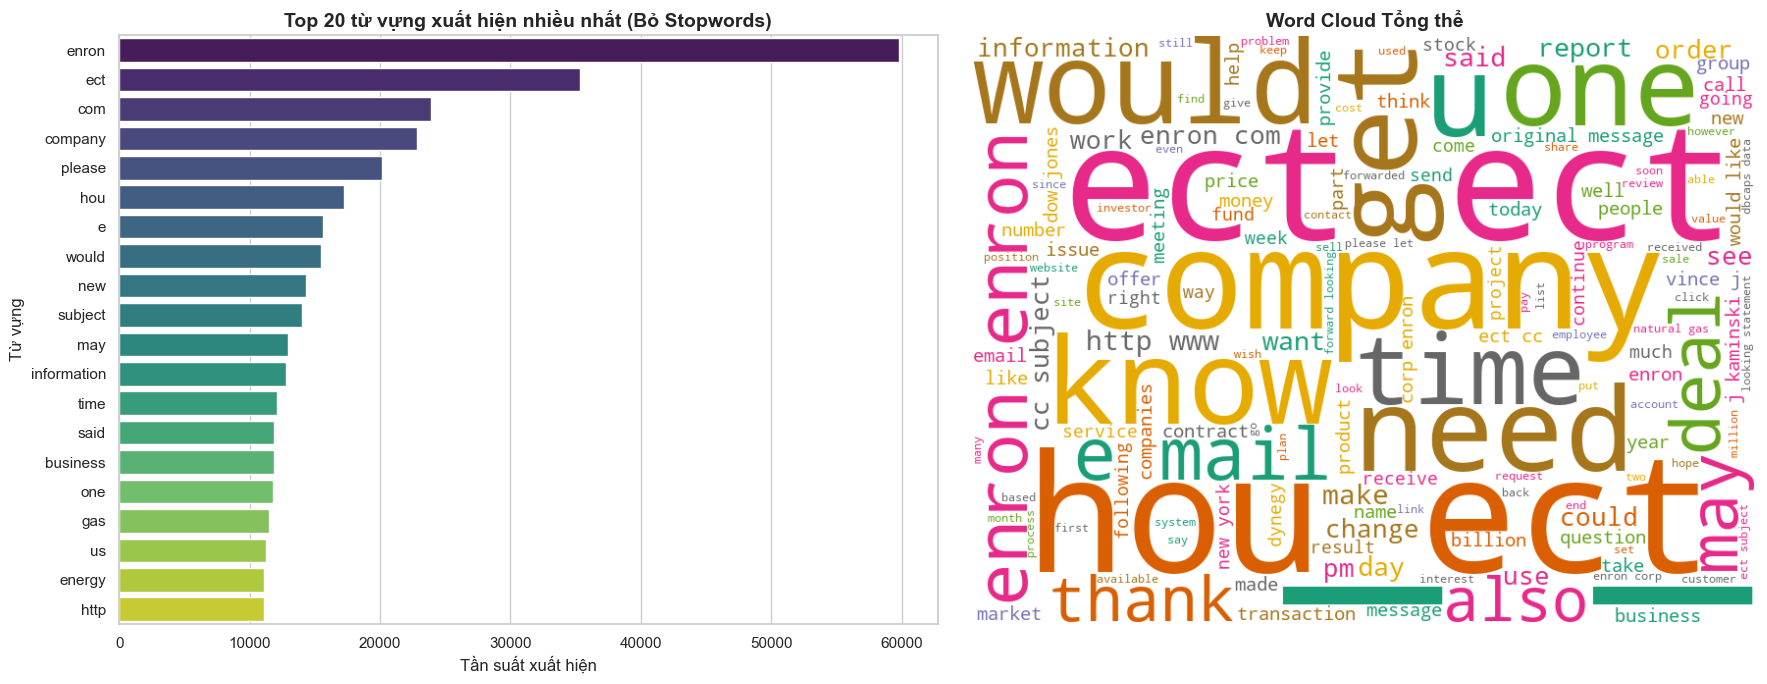

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x='Tần suất', y='Từ vựng', data=df_words, palette='viridis', ax=axes[0])
axes[0].set_title('Top 20 từ vựng xuất hiện nhiều nhất (Bỏ Stopwords)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tần suất xuất hiện')
axes[0].set_ylabel('Từ vựng')

wordcloud_all = WordCloud(width=800, height=600, background_color='white', 
                          colormap='Dark2', stopwords=stop_words, max_words=150).generate(all_text)
axes[1].imshow(wordcloud_all, interpolation='bilinear')
axes[1].axis("off")
axes[1].set_title('Word Cloud Tổng thể', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Dựa trên biểu đồ Top 20 từ vựng xuất hiện nhiều nhất và Word Cloud tổng thể (sau khi đã loại bỏ các Stopwords tiếng Anh cơ bản), nhóm phát hiện ra các Insight có thể ảnh hưởng tới performance của model sau này:
- Các vị trí dẫn đầu gần như bị chiếm trọn bởi các từ định danh đặc thù của công ty: enron, ect (Enron Capital & Trade), hou (Houston - trụ sở), cùng với các từ vựng chuyên ngành của họ như gas (khí đốt), energy (năng lượng). Do bộ dữ liệu này được trích xuất từ vụ bê bối rò rỉ email nội bộ của tập đoàn năng lượng Enron, nên sự xuất hiện dày đặc của các từ vựng mang tính định danh công ty và ngành nghề này là điều tất yếu. Tuy nhiên, chúng xuất hiện ở gần như mọi email công việc, do đó chúng không có khả năng phân biệt giữa thư thường và thư rác. Ngoài ra có vẻ tập dữ liệu đang rất nặng về văn phong công sở của Enron. Sự áp đảo này cảnh báo một nguy cơ cực lớn về Overfitting. Nếu không can thiệp, model sẽ mặc định cứ thấy chữ enron hay ect là gán nhãn thư thường (Ham), khiến nó trở nên vô dụng nếu đem đi phân loại email ở các công ty khác
- Các từ như subject (tiêu đề), com, http, e vẫn nghiễm nhiên lọt vào Top 20. Sự xuất hiện của http và com hoàn toàn khớp với Insight ở phần phân tích Ký tự đặc biệt (sự lọt top của dấu / và dấu .), củng cố thêm bằng chứng về việc email chứa một lượng lớn đường link URL. Các chữ như subject hay message chỉ là các nhãn cấu trúc của một bức thư điện tử, không mang ý nghĩa nội dung
- Mặc dù nhóm đã dùng hàm loại bỏ Stopwords, nhưng các từ ở Top 20 này thực chất chính là Stopwords của riêng bộ dữ liệu Enron. Nếu giữ lại enron hay ect, thuật toán TF-IDF sẽ đánh trọng số cực cao cho chúng vì tần suất quá lớn, làm lu mờ đi những từ khóa thực sự quan trọng dùng để bắt rác

## Bivariate Analysis
Mục tiêu: Đặt hai nhóm dữ liệu Spam và Ham lên bàn cân đối chiếu trực tiếp để tìm ra những đặc trưng phân loại cốt lõi giúp model Machine Learning nhận diện được thủ phạm
- So sánh từ vựng giữa Spam và Ham (Đã loại bỏ các Custom Stopwords đặc thù của Enron (như 'enron', 'ect', 'subject', 'com'))
- So sánh độ dài nội dung email theo label
- So sánh phân bố dấu câu
- Phân tích Cụm từ (Top 10 Bigrams)
- Khám phá xem có sự phân cụm rõ rệt nào giữa số lượng dấu câu và độ dài email khi phân tách theo nhãn hay không

In [91]:
spam_df = enron_dataset[enron_dataset['Spam/Ham'] == 'spam']
ham_df = enron_dataset[enron_dataset['Spam/Ham'] == 'ham']

In [92]:
from wordcloud import STOPWORDS

In [93]:
# Danh sách từ nhiễu đặc thù của Enron phát hiện từ bước Univariate
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['enron', 'ect', 'com', 'company', 'please', 'hou', 'e', 'would', 'new', 'subject', 'may', 'information', 'time', 'said', 'business', 'one', 'gas', 'us', 'energy', 'http','will','one','may','pm','cc','thank'])

In [94]:
# Gộp text
spam_text = " ".join(spam_df['Message'].astype(str))
ham_text = " ".join(ham_df['Message'].astype(str))

In [95]:
# Tạo 2 Word Clouds
wc_spam = WordCloud(width=600, height=500, background_color='black', colormap='Reds', stopwords=custom_stopwords, max_words=100).generate(spam_text)
wc_ham = WordCloud(width=600, height=500, background_color='white', colormap='Greens', stopwords=custom_stopwords, max_words=100).generate(ham_text)

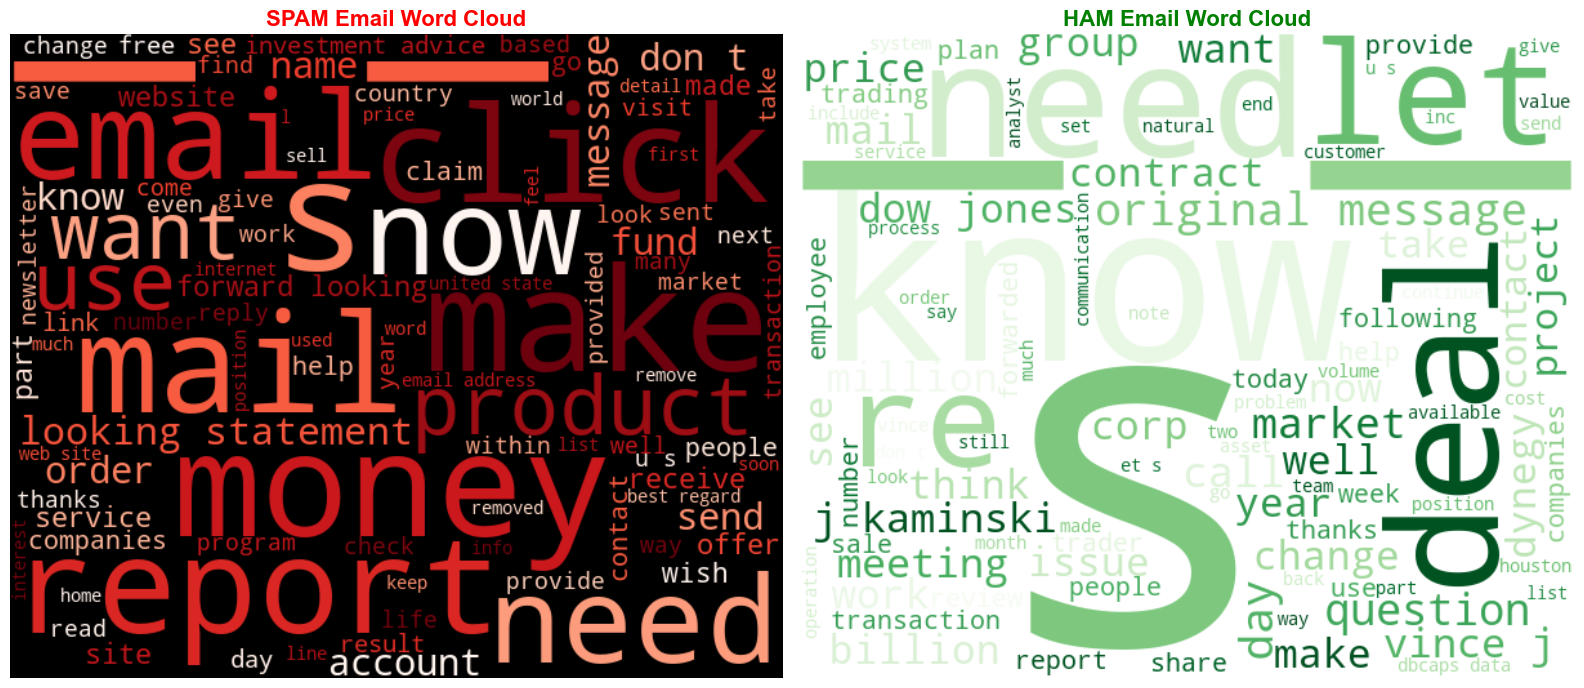

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(wc_spam, interpolation='bilinear')
axes[0].axis("off")
axes[0].set_title('SPAM Email Word Cloud', fontsize=16, fontweight='bold', color='red')

axes[1].imshow(wc_ham, interpolation='bilinear')
axes[1].axis("off")
axes[1].set_title('HAM Email Word Cloud', fontsize=16, fontweight='bold', color='green')
plt.tight_layout()
plt.show()

- Nhóm từ vựng của Spam mang đậm tính chất quảng cáo và lừa đảo: click, now, make, money, product, want. Chiến lược của kẻ gửi Spam rất rõ ràng. Chúng tạo ra sự cấp bách (now) để thúc giục nạn nhân thực hiện hành động (click, use) nhằm đạt được một lợi ích tài chính hoặc mồi chài mua bán (make money, product). Đây là các dấu hiệu kinh điển của Email Marketing rác và Phishing
- Từ vựng của Ham phản ánh chính xác nhịp độ làm việc tại một siêu tập đoàn năng lượng như Enron: deal (thỏa thuận), billion (tỷ), price (giá cả), issue (vấn đề), work (công việc).Cùng với đó là văn phong giao tiếp công sở chuẩn mực: let, know (hãy cho tôi biết), contact

In [97]:
def get_top_ngrams(corpus, n=2, top_k=10):
    all_ngrams = []
    
    for text in corpus:
        tokens = re.findall(r'\b[A-Za-z]+\b', str(text).lower())
        
        clean_tokens = [word for word in tokens if word not in custom_stopwords]
        
        if len(clean_tokens) >= n:
            all_ngrams.extend(ngrams(clean_tokens, n))
    ngram_counts = Counter(all_ngrams)
    
    top_ngrams = ngram_counts.most_common(top_k)
    
    # Chuyển đổi định dạng từ Tuple (('word1', 'word2'), 100) -> Danh sách [('word1 word2', 100)]
    words_freq = [(' '.join(ngram), count) for ngram, count in top_ngrams]
    
    return pd.DataFrame(words_freq, columns=['Bigram', 'Tần suất'])

In [98]:
top_spam_bigrams = get_top_ngrams(spam_df['Message'].astype(str))
top_ham_bigrams = get_top_ngrams(ham_df['Message'].astype(str))

In [99]:
top_spam_bigrams['Bigram'].tolist()

['looking statements',
 'don t',
 'forward looking',
 'investment advice',
 'u s',
 'within email',
 'risks uncertainties',
 'email address',
 'best regards',
 'united states']

In [100]:
top_ham_bigrams['Bigram'].tolist()

['let know',
 'original message',
 'j kaminski',
 'vince j',
 'dow jones',
 'dbcaps data',
 'don t',
 'u s',
 'et s',
 'rights reserved']

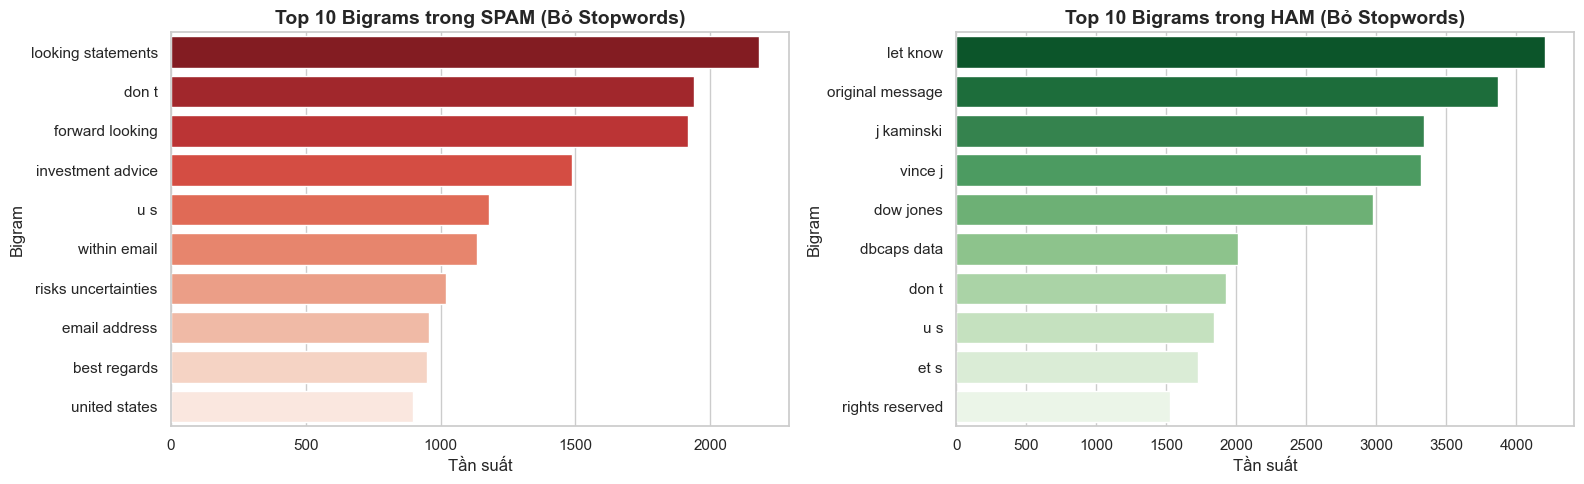

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x='Tần suất', y='Bigram', data=top_spam_bigrams, ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Bigrams trong SPAM (Bỏ Stopwords)', fontsize=14, fontweight='bold')

sns.barplot(x='Tần suất', y='Bigram', data=top_ham_bigrams, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Bigrams trong HAM (Bỏ Stopwords)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Dựa trên danh sách Top 10 Bigrams thực tế được trích xuất từ dữ liệu, nhóm phát hiện ra những quy luật cực kỳ rõ rệt và mang tính đặc thù cao của tập dữ liệu này:
- Khác với các loại thư rác thông thường, Spam trong tập dữ liệu này ngập tràn các thuật ngữ pháp lý và đầu tư tài chính: looking statements, forward looking, investment advice (lời khuyên đầu tư), risks uncertainties (rủi ro và tính không chắc chắn). Đây là kịch bản kinh điển của các email lừa đảo Bơm và Xả cổ phiếu. Những kẻ lừa đảo gửi email xúi giục nạn nhân mua một mã cổ phiếu rác để thổi giá, và chúng luôn chèn thêm cụm từ "forward-looking statements" (các tuyên bố hướng tới tương lai) để lách luật và trốn tránh trách nhiệm pháp lý. Cụm 000 00 là minh chứng rõ ràng cho việc hứa hẹn các khoản tiền khổng lồ (ví dụ: $10,000.00). Ngoài ra cụm http www đứng chễm chệ ở vị trí số 1 khẳng định lại việc Spam chứa rất nhiều đường link dẫn dụ nạn nhân
- Biểu đồ Ham bị thống trị hoàn toàn bởi các cụm từ định danh công ty: hou ect, ect ect, enron enron, enron com, corp enron (Houston, Enron Capital & Trade), từ đó ta thấy được thư Ham thực sự là những đoạn hội thoại nội bộ khép kín. Các cụm let know (hãy cho tôi biết) thể hiện văn phong làm việc, trong khi cc subject và original message là tàn dư của các chuỗi email reply/forward kéo dài. Đáng chú ý nhất là sự xuất hiện của cái tên vince kaminski. (Vince Kaminski là giám đốc nghiên cứu định lượng của Enron, người có hộp thư bị rò rỉ và chiếm tỷ trọng cực lớn trong bộ dữ liệu này)

-> Nếu không can thiệp, mô hình sẽ học thuộc lòng cái tên vince kaminski hoặc chữ ect và mặc định đó là Ham. Nhóm BẮT BUỘC phải nạp thêm tên người (vince, kaminski) và các biến thể tổ chức (hou, ect, corp) vào danh sách Custom Stopwords để triệt tiêu sự thiên lệch (bias) này, và các cụm http www đòi hỏi nhóm phải dùng Regex dọn sạch link web ra khỏi văn bản, giữ lại các cụm từ tài chính bên Spam vì đây chính là tín hiệu để thuật toán TF-IDF phân loại rác

In [102]:
enron_dataset.groupby('Spam/Ham')['Message_Length'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Spam/Ham,,,,,,,,
ham,16493.0,356.59,1149.37,1.0,67.0,170.0,366.0,45448.0
spam,16852.0,258.02,388.47,1.0,66.0,130.0,272.0,8386.0


In [103]:
enron_dataset.groupby('Spam/Ham')['Punct_Count'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Spam/Ham,,,,,,,,
ham,16493.0,85.33,225.45,0.0,13.0,36.0,97.0,8313.0
spam,16852.0,53.00,98.66,0.0,11.0,27.0,57.0,3651.0


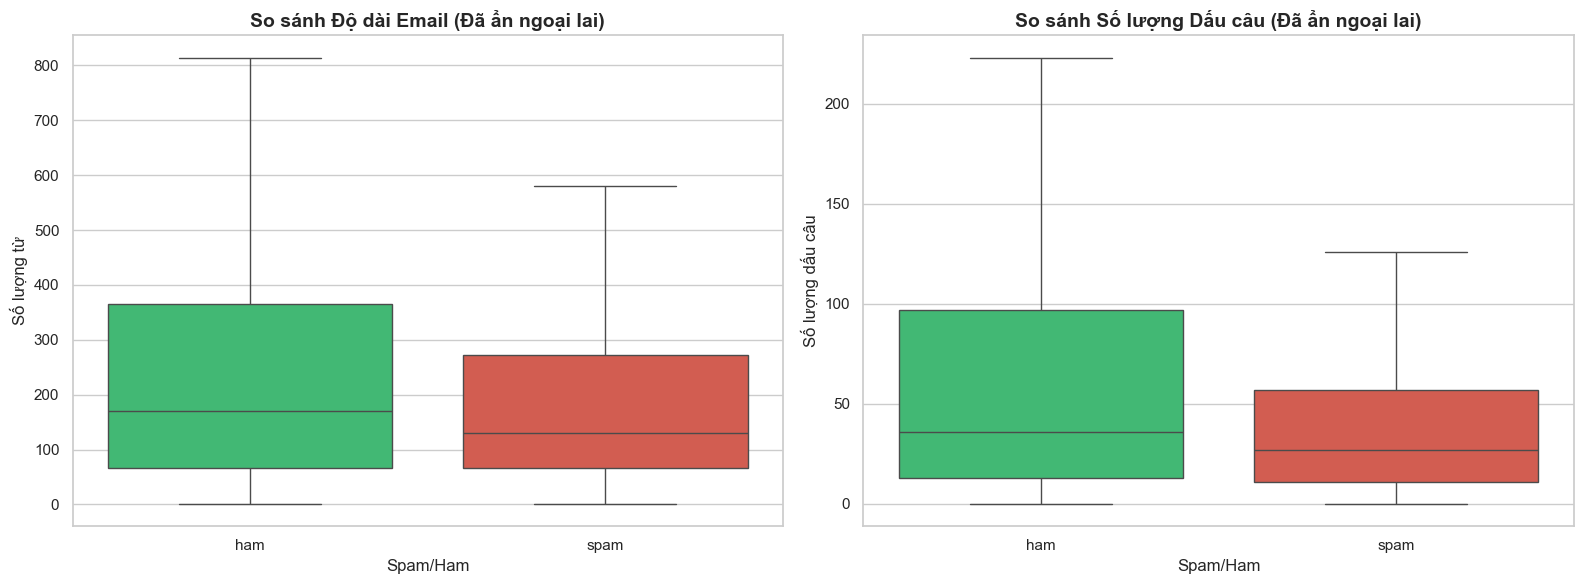

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Boxplot Độ dài Email (Giới hạn trục Y để nhìn rõ phần trung vị, cắt bớt outliers khổng lồ hiển thị)
sns.boxplot(x='Spam/Ham', y='Message_Length', data=enron_dataset, ax=axes[0], palette={'ham': '#2ecc71', 'spam': '#e74c3c'}, showfliers=False)
axes[0].set_title('So sánh Độ dài Email (Đã ẩn ngoại lai)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Số lượng từ')

# Boxplot Số lượng dấu câu
sns.boxplot(x='Spam/Ham', y='Punct_Count', data=enron_dataset, ax=axes[1], palette={'ham': '#2ecc71', 'spam': '#e74c3c'}, showfliers=False)
axes[1].set_title('So sánh Số lượng Dấu câu (Đã ẩn ngoại lai)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Số lượng dấu câu')

plt.tight_layout()
plt.show()

Dựa trên bảng thống kê chi tiết từ biểu đồ Boxplot, nhóm đã phát hiện ra những quy luật phân bố đi ngược lại với trực giác thông thường, qua đó làm lộ rõ bản chất của tập dữ liệu Enron:
- Trái với suy nghĩ Spam thường dài lê thê, số liệu cho thấy Trung vị (50%) độ dài của Ham là 170 từ, cao hơn đáng kể so với Spam (130 từ). Mức trung bình (Mean) của Ham cũng áp đảo với 356.59 từ so với 258.02 từ của Spam. Thư rác thực chất thường được thiết kế ngắn gọn, đánh nhanh thắng nhanh bằng một vài câu giật tít để lừa nạn nhân click vào link. Ngược lại, thư công việc nội bộ của Enron (Ham) lại cực kỳ dài vì chúng thường chứa các bản báo cáo chi tiết, hợp đồng pháp lý, hoặc các chuỗi email chuyển tiếp (forward/reply) lồng nhau kéo dài qua nhiều ngày
- Trung vị số lượng dấu câu của Ham là 36 dấu, cao hơn Spam (27 dấu). Đỉnh điểm, email Ham nhiều dấu câu nhất lên tới 8.313 dấu, vượt xa mức tối đa của Spam (3.651 dấu).Vì Ham dài hơn nên việc chứa nhiều dấu câu hơn là điều tất yếu về mặt toán học. Hơn nữa, thư công việc bắt buộc phải tuân thủ ngữ pháp chuẩn xác (chấm, phẩy) và sử dụng nhiều ký tự định dạng cấu trúc nội bộ (như --- Forwarded by ---, >). Spam tuy có lạm dụng mã HTML (như phát hiện ở bước Bigrams) nhưng tổng thể vẫn không thể đọ lại khối lượng văn bản khổng lồ của Ham
- Độ lệch chuẩn về độ dài của Ham lên tới 1149.37, lớn gấp gần 3 lần so với độ lệch chuẩn của Spam (388.47). Cùng với đó, điểm max của Ham đạt mức kỷ lục 45.448 từ, trong khi Spam lớn nhất chỉ đạt 8.386 từ. Thư Spam thường được tạo ra một cách công nghiệp từ các phần mềm gửi tự động dựa trên một vài bộ khung (template) có sẵn, do đó độ dài của chúng có tính ổn định và ít biến động. Ngược lại, thư con người viết (Ham) thì thiên biến vạn hóa: có thể chỉ là một từ "OK" (min=1), nhưng cũng có thể là một cuốn sổ tay nhân viên dài 45 ngàn từ

-> Biến Message_Length và Punct_Count mang lại giá trị phân loại rất cao. Nếu email ngắn và ít biến động, tỷ lệ cao đó là Spam. Nhóm sẽ giữ lại hai biến số học này để kết hợp cùng ma trận TF-IDF trong quá trình train model ở giai đoạn sau

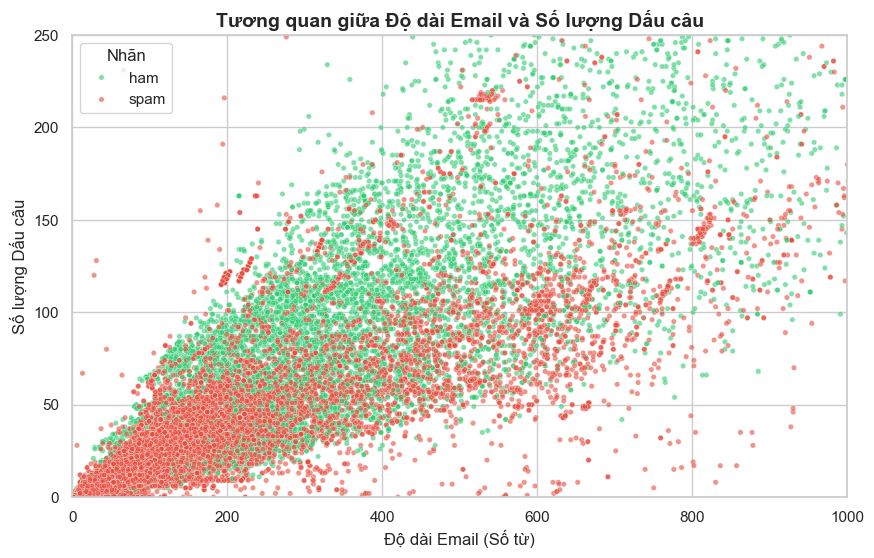

In [105]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=enron_dataset, x='Message_Length', y='Punct_Count', hue='Spam/Ham', palette={'ham': '#2ecc71', 'spam': '#e74c3c'}, alpha=0.6, s=15)

plt.title('Tương quan giữa Độ dài Email và Số lượng Dấu câu', fontsize=14, fontweight='bold')
plt.xlabel('Độ dài Email (Số từ)')
plt.ylabel('Số lượng Dấu câu')
plt.xlim(0, 1000) # Chỉ xem xét cụm dữ liệu phổ biến dưới 1000 từ
plt.ylim(0, 250)  
plt.legend(title='Nhãn')
plt.show()

## Outlier Detection

In [106]:
Q1 = enron_dataset['Message_Length'].quantile(0.25)
Q3 = enron_dataset['Message_Length'].quantile(0.75)
IQR = Q3 - Q1

# Vì độ dài email không thể âm, ta chỉ quan tâm đến điểm chặn trên
upper_bound = Q3 + 1.5 * IQR

outliers_df = enron_dataset[enron_dataset['Message_Length'] > upper_bound]
normal_df = enron_dataset[enron_dataset['Message_Length'] <= upper_bound]

In [107]:
print(f"▶ Q1 (25%): {Q1} từ")
print(f"▶ Q3 (75%): {Q3} từ")
print(f"▶ Ngưỡng giới hạn trên (Upper Bound): {upper_bound} từ")
print(f"▶ Tổng số email Ngoại lai (vượt ngưỡng): {len(outliers_df)} email (Chiếm {(len(outliers_df)/len(enron_dataset))*100:.2f}%)")
print(f"▶ Tổng số email Bình thường được giữ lại: {len(normal_df)} email")

▶ Q1 (25%): 67.0 từ
▶ Q3 (75%): 326.0 từ
▶ Ngưỡng giới hạn trên (Upper Bound): 714.5 từ
▶ Tổng số email Ngoại lai (vượt ngưỡng): 2673 email (Chiếm 8.02%)
▶ Tổng số email Bình thường được giữ lại: 30672 email


In [108]:
outliers_df['Spam/Ham'].value_counts()

Spam/Ham
ham     1459
spam    1214
Name: count, dtype: int64

Dựa trên kết quả chạy thuật toán IQR trên biến Message_Length (Độ dài email), nhóm rút ra các đánh giá định lượng và quyết định xử lý như sau:
- Thuật toán chỉ ra rằng bất kỳ email nào dài hơn 715 từ sẽ bị coi là bất thường. Con số này được xem là hợp lý với thực tiễn giao tiếp. Một email công việc hoặc quảng cáo thông thường hiếm khi vượt quá mốc này (tương đương khoảng 2 trang A4). Những văn bản dài hơn 715 từ chủ yếu là các tàn dư cấu trúc (chuỗi forward email lồng nhau qua nhiều tháng), các bản báo cáo đính kèm bị dump thành text, hoặc mã HTML rác. Việc model cố gắng học từ các văn bản dị biệt này sẽ gây ra hiện tượng noise và overfitting
- Tổng số lượng Outlier phát hiện được là 2.673 email, chiếm 8.02% tổng số lượng tập dữ liệu. Với tỷ lệ này ta có thể cắt bỏ dưới 10% dữ liệu outlier mà không làm hỏng cấu trúc phân bố gốc. Việc giữ lại hơn 30.672 email bình thường là một khối lượng dữ liệu quá đủ để để train model
- Từ kết quả thống kê là sự phân bố ngoại lai ở 2 nhãn tương đối đồng đều: 1.459 Ham và 1.214 Spam. Nếu outlier chỉ tập trung toàn bộ ở một nhóm (ví dụ chỉ mất Spam), việc xóa chúng sẽ làm mất cân bằng tập dữ liệu. Nhưng vì cả hai bên đều "rụng" đi một lượng tương đương nhau, việc cắt bỏ phần đuôi này sẽ không làm thay đổi tỷ lệ Spam/Ham tổng thể của bài toán

In [109]:
enron_dataset = normal_df.copy()

# Reset lại index sau khi xóa dòng để tránh lỗi khi đưa vào model
enron_dataset.reset_index(drop=True, inplace=True)

In [110]:
enron_dataset.shape

(30672, 7)

In [111]:
pd.set_option('display.max_colwidth', None)
enron_dataset.head(10)

,Message ID,Subject,Message,Spam/Ham,Date,Message_Length,Punct_Count
0,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14,8,2
1,3,re : issue,"fyi - see note below - already done .\nstella\n- - - - - - - - - - - - - - - - - - - - - - forwarded by stella l morris / hou / ect on 12 / 14 / 99 10 : 18\nam - - - - - - - - - - - - - - - - - - - - - - - - - - -\nfrom : sherlyn schumack on 12 / 14 / 99 10 : 06 am\nto : stella l morris / hou / ect @ ect\ncc : howard b camp / hou / ect @ ect\nsubject : re : issue\nstella ,\nthis has already been taken care of . you did this for me yesterday .\nthanks .\nhoward b camp\n12 / 14 / 99 09 : 10 am\nto : stella l morris / hou / ect @ ect\ncc : sherlyn schumack / hou / ect @ ect , howard b camp / hou / ect @ ect , stacey\nneuweiler / hou / ect @ ect , daren j farmer / hou / ect @ ect\nsubject : issue\nstella ,\ncan you work with stacey or daren to resolve\nhc\n- - - - - - - - - - - - - - - - - - - - - - forwarded by howard b camp / hou / ect on 12 / 14 / 99 09 : 08\nam - - - - - - - - - - - - - - - - - - - - - - - - - - -\nfrom : sherlyn schumack 12 / 13 / 99 01 : 14 pm\nto : howard b camp / hou / ect @ ect\ncc :\nsubject : issue\ni have to create accounting arrangement for purchase from unocal energy at\nmeter 986782 . deal not tracked for 5 / 99 . volume on deal 114427 expired 4 / 99 .",ham,1999-12-14,344,169
2,4,meter 7268 nov allocation,"fyi .\n- - - - - - - - - - - - - - - - - - - - - - forwarded by lauri a allen / hou / ect on 12 / 14 / 99 12 : 17\npm - - - - - - - - - - - - - - - - - - - - - - - - - - -\nkimberly vaughn\n12 / 10 / 99 02 : 54 pm\nto : lauri a allen / hou / ect @ ect\ncc : mary m smith / hou / ect @ ect\nsubject : meter 7268 nov allocation\nlauri . . i have put this on strangas gas until i can get a contract from\ndaren .\n- - - - - - - - - - - - - - - - - - - - - - forwarded by kimberly vaughn / hou / ect on 12 / 10 / 99 01 : 52\npm - - - - - - - - - - - - - - - - - - - - - - - - - - -\nlauri a allen\n12 / 09 / 99 01 : 20 pm\nto : kimberly vaughn / hou / ect @ ect , anita luong / hou / ect @ ect\ncc : howard b camp / hou / ect @ ect , mary m smith / hou / ect @ ect\nsubject : meter 7268 nov allocation\nkim / anita -\na volume of 7247 mm shows to have been allocated to the reliant 201 contract\nfor november . there was no nomination for reliant at this point in november\nand , therefore , there should be no volume allocated to their contract .\nplease make sure these volumes are moved off the reliant contract prior to\nnovember close .\nthanks .",ham,1999-12-14,318,152
3,5,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is shut in on 10 / 19 / 99 ( the last day of\nflow ) :\nat what meter is the mcmullen gas being diverted to ?\nat what meter is hpl buying the residue gas ? ( this is the gas from teco ,\nvastar , vintage , tejones , and swift )\ni still see active deals at meter 3405 in path manager for teco , vastar ,\nvintage , tejones , and swift\ni also see gas scheduled in pops at meter 3404 and 3405 .\nplease advice . we need to resolve this as soon as possible so settlement\ncan send out payments .\nthanks",ham,1999-12-14,119,21
4,6,meter 1517 - jan 1999,"george ,\ni need the following done :\njan 13\nzero out 012 - 27049 - 02 - 001 receipt package id 2666\nallocate flow of 149 to 012 - 64610 - 02 - 055 deliv package id 392\njan 26\nzero out 012 - 27049 - 02 - 001 receipt package id 3011\nzero out 012 - 64610 - 02 - 055 deliv package id 392\nthese were buybacks that were incorrectly nominated to transport contracts\n( ect 201 receipt )\nlet me know when this is done\nhc",ham,1999-12-14,90,16
5,7,duns number changes,"fyi\n- - - - - - - - - - - - - - - - - - - - - - forwarded by gary l payne / hou / ect on 12 / 14 / 99 02 : 35 pm\n- - - - - - - - - - - - - - - - - - - - - - - - - - -\nfrom : antoine v pierre 12 / 14 / 99 02 : 34 pm\nto : tommy j yanowski / hou / ect @ ect , kathryn bussell / hou / ect @ ect , gary 

In [112]:
enron_dataset.columns.tolist()

['Message ID',
 'Subject',
 'Message',
 'Spam/Ham',
 'Date',
 'Message_Length',
 'Punct_Count']

In [113]:
columns_to_keep = ['Subject','Message', 'Spam/Ham', 'Message_Length', 'Punct_Count']
existing_columns = [col for col in columns_to_keep if col in enron_dataset.columns]
enron_dataset = enron_dataset[existing_columns]

In [114]:
enron_dataset.columns.tolist()

['Subject', 'Message', 'Spam/Ham', 'Message_Length', 'Punct_Count']

In [115]:
pd.set_option('display.max_colwidth', None)
enron_dataset[['Message', 'Spam/Ham']].head(20)

,Message,Spam/Ham
0,- calpine daily gas nomination 1 . doc,ham
1,"fyi - see note below - already done .\nstella\n- - - - - - - - - - - - - - - - - - - - - - forwarded by stella l morris / hou / ect on 12 / 14 / 99 10 : 18\nam - - - - - - - - - - - - - - - - - - - - - - - - - - -\nfrom : sherlyn schumack on 12 / 14 / 99 10 : 06 am\nto : stella l morris / hou / ect @ ect\ncc : howard b camp / hou / ect @ ect\nsubject : re : issue\nstella ,\nthis has already been taken care of . you did this for me yesterday .\nthanks .\nhoward b camp\n12 / 14 / 99 09 : 10 am\nto : stella l morris / hou / ect @ ect\ncc : sherlyn schumack / hou / ect @ ect , howard b camp / hou / ect @ ect , stacey\nneuweiler / hou / ect @ ect , daren j farmer / hou / ect @ ect\nsubject : issue\nstella ,\ncan you work with stacey or daren to resolve\nhc\n- - - - - - - - - - - - - - - - - - - - - - forwarded by howard b camp / hou / ect on 12 / 14 / 99 09 : 08\nam - - - - - - - - - - - - - - - - - - - - - - - - - - -\nfrom : sherlyn schumack 12 / 13 / 99 01 : 14 pm\nto : howard b camp / hou / ect @ ect\ncc :\nsubject : issue\ni have to create accounting arrangement for purchase from unocal energy at\nmeter 986782 . deal not tracked for 5 / 99 . volume on deal 114427 expired 4 / 99 .",ham
2,"fyi .\n- - - - - - - - - - - - - - - - - - - - - - forwarded by lauri a allen / hou / ect on 12 / 14 / 99 12 : 17\npm - - - - - - - - - - - - - - - - - - - - - - - - - - -\nkimberly vaughn\n12 / 10 / 99 02 : 54 pm\nto : lauri a allen / hou / ect @ ect\ncc : mary m smith / hou / ect @ ect\nsubject : meter 7268 nov allocation\nlauri . . i have put this on strangas gas until i can get a contract from\ndaren .\n- - - - - - - - - - - - - - - - - - - - - - forwarded by kimberly vaughn / hou / ect on 12 / 10 / 99 01 : 52\npm - - - - - - - - - - - - - - - - - - - - - - - - - - -\nlauri a allen\n12 / 09 / 99 01 : 20 pm\nto : kimberly vaughn / hou / ect @ ect , anita luong / hou / ect @ ect\ncc : howard b camp / hou / ect @ ect , mary m smith / hou / ect @ ect\nsubject : meter 7268 nov allocation\nkim / anita -\na volume of 7247 mm shows to have been allocated to the reliant 201 contract\nfor november . there was no nomination for reliant at this point in november\nand , therefore , there should be no volume allocated to their contract .\nplease make sure these volumes are moved off the reliant contract prior to\nnovember close .\nthanks .",ham
3,"jackie ,\nsince the inlet to 3 river plant is shut in on 10 / 19 / 99 ( the last day of\nflow ) :\nat what meter is the mcmullen gas being diverted to ?\nat what meter is hpl buying the residue gas ? ( this is the gas from teco ,\nvastar , vintage , tejones , and swift )\ni still see active deals at meter 3405 in path manager for teco , vastar ,\nvintage , tejones , and swift\ni also see gas scheduled in pops at meter 3404 and 3405 .\nplease advice . we need to resolve this as soon as possible so settlement\ncan send out payments .\nthanks",ham
4,"george ,\ni need the following done :\njan 13\nzero out 012 - 27049 - 02 - 001 receipt package id 2666\nallocate flow of 149 to 012 - 64610 - 02 - 055 deliv package id 392\njan 26\nzero out 012 - 27049 - 02 - 001 receipt package id 3011\nzero out 012 - 64610 - 02 - 055 deliv package id 392\nthese were buybacks that were incorrectly nominated to transport contracts\n( ect 201 receipt )\nlet me know when this is done\nhc",ham
5,"fyi\n- - - - - - - - - - - - - - - - - - - - - - forwarded by gary l payne / hou / ect on 12 / 14 / 99 02 : 35 pm\n- - - - - - - - - - - - - - - - - - - - - - - - - - -\nfrom : antoine v pierre 12 / 14 / 99 02 : 34 pm\nto : tommy j yanowski / hou / ect @ ect , kathryn bussell / hou / ect @ ect , gary l\npayne / hou / ect @ ect , diane e niestrath / hou / ect @ ect , romeo d ' souza / hou / ect @ ect ,\nmichael eiben / hou / ect @ ect , clem cernosek / hou / ect @ ect , scotty\ngilbert / hou / ect @ ect , dave nommensen / hou / ect @ ect , david rohan / hou / ect @ ect ,\nkevin he

# Data Preprocessing
Mục tiêu: Biến các đoạn email thô lộn xộn thành văn bản tinh khiết
- Data Cleaning:
    - Xóa dữ liệu duplicate: Quét và loại bỏ các dòng có nội dung email giống hệt nhau, chỉ giữ lại bản ghi đầu tiên
    - Gộp cột Subject (đã được Impute từ bước EDA) và Message thành một cột duy nhất Full_Text, sau đó xóa 2 cột thô cũ đi
    - Dùng Regex thay thế toàn bộ đường link thành URLTOKEN
    - Dùng Regex thay thế toàn bộ chữ số/tiền tệ thành NUMTOKEN
    - Lowercasing: Chuyển toàn bộ văn bản về chữ thường
    - Xóa sạch mã HTML (bằng Regex)
    - Xóa toàn bộ dấu câu và ký tự đặc biệt (chỉ giữ lại chữ cái và các Token vừa tạo)
    - Chuẩn hóa khoảng trắng (xóa khoảng trắng thừa, dấu tab, dấu xuống dòng liên tiếp)
- Text Transformation:
    - Tokenization (Tách câu thành các từ đơn)
    - Xóa Custom Stopwords: Lọc bỏ các từ dừng tiếng Anh (NLTK) cộng với danh sách từ nhiễu tập đoàn (enron, ect, hou, re, s...) đã tìm ra ở bước EDA
    - Lemmatization (Đưa từ vựng về dạng nguyên thể, ví dụ: running -> run)

In [116]:
import pandas as pd
import re, nltk, string #RegEx
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

In [117]:
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)

True

In [118]:
# Xóa Duplicate
initial_shape = enron_dataset.shape[0]
enron_dataset = enron_dataset.drop_duplicates(subset=['Message'], keep='first').reset_index(drop=True)

In [119]:
enron_dataset.shape[0]

27385

In [120]:
# Merge Subject vào Message
enron_dataset['Full_Text'] = enron_dataset['Subject'].astype(str) + " " + enron_dataset['Message'].astype(str)
enron_dataset = enron_dataset.drop(columns=['Subject', 'Message'])

In [129]:
enron_dataset.columns

Index(['Spam/Ham', 'Message_Length', 'Punct_Count', 'Full_Text'], dtype='str')

In [121]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
custom_stops = {
    'enron', 'ect', 'com', 'company', 'please', 'hou', 'e', 'would', 'new', 'subject', 'may', 'information', 'time', 'said', 'business', 'one', 'gas', 'us', 'energy', 'http','will','one','may','pm','cc','thank'
}
stop_words.update(custom_stops)

In [122]:
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): 
        return wordnet.ADJ
    elif treebank_tag.startswith('V'): 
        return wordnet.VERB
    elif treebank_tag.startswith('N'): 
        return wordnet.NOUN
    elif treebank_tag.startswith('R'): 
        return wordnet.ADV
    else: 
        return wordnet.NOUN # Mặc định là Noun

In [123]:
dirty_sample = """- - - - - - - - - - - - - - - - - - - - - - forwarded by susan d trevino / hou / ect on 12 / 15 / 99 08 : 41\nam - - - - - - - - - - - - - - - - - - - - - - - - - - -\nbob withers on 12 / 15 / 99 08 : 28 : 08 am\nto : susan d trevino / hou / ect @ ect\ncc : stretch brennan , kevin mclarney ,\n" ' taylor vance ( e - mail ) ' "\nsubject : 2 nd rev dec . 1999 josey ranch nom\nhere ' s revised december 1999 ( effective 12 / 15 / 99 ) setup for\njosey : ( using 1 . 081 btu / mcf )\n* gas deliveries into hpl\n9 , 300 mmbtu / d for kri ( net reduction of\n3 , 000 mmbtu / d )\n9 , 300 mmbtu / d into hpl\nbob withers > <\nkcs energy , 5555 san felipe , suite 1200\nhouston , tx 77056\nvoice mail / page 713 - 964 - 9434"""

In [124]:
cleaned = str(dirty_sample).encode('ascii', 'ignore').decode('ascii')
cleaned

'- - - - - - - - - - - - - - - - - - - - - - forwarded by susan d trevino / hou / ect on 12 / 15 / 99 08 : 41\nam - - - - - - - - - - - - - - - - - - - - - - - - - - -\nbob withers on 12 / 15 / 99 08 : 28 : 08 am\nto : susan d trevino / hou / ect @ ect\ncc : stretch brennan , kevin mclarney ,\n" \' taylor vance ( e - mail ) \' "\nsubject : 2 nd rev dec . 1999 josey ranch nom\nhere \' s revised december 1999 ( effective 12 / 15 / 99 ) setup for\njosey : ( using 1 . 081 btu / mcf )\n* gas deliveries into hpl\n9 , 300 mmbtu / d for kri ( net reduction of\n3 , 000 mmbtu / d )\n9 , 300 mmbtu / d into hpl\nbob withers > <\nkcs energy , 5555 san felipe , suite 1200\nhouston , tx 77056\nvoice mail / page 713 - 964 - 9434'

In [125]:
cleaned = re.sub(r'<[^>]+>', ' ', cleaned)
cleaned = re.sub(r'(https?://\S+|www\.\S+)', ' urltoken ', cleaned)
cleaned

'- - - - - - - - - - - - - - - - - - - - - - forwarded by susan d trevino / hou / ect on 12 / 15 / 99 08 : 41\nam - - - - - - - - - - - - - - - - - - - - - - - - - - -\nbob withers on 12 / 15 / 99 08 : 28 : 08 am\nto : susan d trevino / hou / ect @ ect\ncc : stretch brennan , kevin mclarney ,\n" \' taylor vance ( e - mail ) \' "\nsubject : 2 nd rev dec . 1999 josey ranch nom\nhere \' s revised december 1999 ( effective 12 / 15 / 99 ) setup for\njosey : ( using 1 . 081 btu / mcf )\n* gas deliveries into hpl\n9 , 300 mmbtu / d for kri ( net reduction of\n3 , 000 mmbtu / d )\n9 , 300 mmbtu / d into hpl\nbob withers > <\nkcs energy , 5555 san felipe , suite 1200\nhouston , tx 77056\nvoice mail / page 713 - 964 - 9434'

In [126]:
cleaned = re.sub(r'\b\d+\b', ' numtoken ', cleaned)
cleaned

'- - - - - - - - - - - - - - - - - - - - - - forwarded by susan d trevino / hou / ect on  numtoken  /  numtoken  /  numtoken   numtoken  :  numtoken \nam - - - - - - - - - - - - - - - - - - - - - - - - - - -\nbob withers on  numtoken  /  numtoken  /  numtoken   numtoken  :  numtoken  :  numtoken  am\nto : susan d trevino / hou / ect @ ect\ncc : stretch brennan , kevin mclarney ,\n" \' taylor vance ( e - mail ) \' "\nsubject :  numtoken  nd rev dec .  numtoken  josey ranch nom\nhere \' s revised december  numtoken  ( effective  numtoken  /  numtoken  /  numtoken  ) setup for\njosey : ( using  numtoken  .  numtoken  btu / mcf )\n* gas deliveries into hpl\n numtoken  ,  numtoken  mmbtu / d for kri ( net reduction of\n numtoken  ,  numtoken  mmbtu / d )\n numtoken  ,  numtoken  mmbtu / d into hpl\nbob withers > <\nkcs energy ,  numtoken  san felipe , suite  numtoken \nhouston , tx  numtoken \nvoice mail / page  numtoken  -  numtoken  -  numtoken '

In [127]:
cleaned = cleaned.lower()
cleaned = re.sub(f"[{re.escape(string.punctuation)}]", ' ', cleaned)

cleaned = re.sub(r'\s+', ' ', cleaned).strip()
cleaned

'forwarded by susan d trevino hou ect on numtoken numtoken numtoken numtoken numtoken am bob withers on numtoken numtoken numtoken numtoken numtoken numtoken am to susan d trevino hou ect ect cc stretch brennan kevin mclarney taylor vance e mail subject numtoken nd rev dec numtoken josey ranch nom here s revised december numtoken effective numtoken numtoken numtoken setup for josey using numtoken numtoken btu mcf gas deliveries into hpl numtoken numtoken mmbtu d for kri net reduction of numtoken numtoken mmbtu d numtoken numtoken mmbtu d into hpl bob withers kcs energy numtoken san felipe suite numtoken houston tx numtoken voice mail page numtoken numtoken numtoken'

In [128]:
tokens = nltk.word_tokenize(cleaned)
pos_tags = nltk.pos_tag(tokens)
pos_tags[:10]

[('forwarded', 'VBN'),
 ('by', 'IN'),
 ('susan', 'JJ'),
 ('d', 'NN'),
 ('trevino', 'NN'),
 ('hou', 'NN'),
 ('ect', 'VBP'),
 ('on', 'IN'),
 ('numtoken', 'NNS'),
 ('numtoken', 'JJ')]

In [130]:
final_tokens = []
for word, tag in pos_tags:
    wn_tag = get_wordnet_pos(tag)
    lemma = lemmatizer.lemmatize(word, pos=wn_tag)
    
    if lemma not in stop_words and len(lemma) > 1:
        final_tokens.append(lemma)

cleaned = ' '.join(final_tokens)
cleaned

'forward susan trevino numtoken numtoken numtoken numtoken numtoken bob withers numtoken numtoken numtoken numtoken numtoken numtoken susan trevino stretch brennan kevin mclarney taylor vance mail numtoken nd rev dec numtoken josey ranch nom revise december numtoken effective numtoken numtoken numtoken setup josey use numtoken numtoken btu mcf delivery hpl numtoken numtoken mmbtu kri net reduction numtoken numtoken mmbtu numtoken numtoken mmbtu hpl bob withers kcs numtoken san felipe suite numtoken houston tx numtoken voice mail page numtoken numtoken numtoken'

In [131]:
def clean_text(text):
    cleaned = '' if pd.isna(text) else str(text)
    cleaned = cleaned.encode('ascii', 'ignore').decode('ascii') # Fix Unicode
    
    # Xóa HTML, URL, Số (Cập nhật Regex mới)
    cleaned = re.sub(r'<[^>]+>', ' ', cleaned)
    cleaned = re.sub(r'(https?://\S+|www\.\S+)', ' urltoken ', cleaned)
    cleaned = re.sub(r'\b\d+\b', ' numtoken ', cleaned)
    
    cleaned = cleaned.lower()
    cleaned = re.sub(f"[{re.escape(string.punctuation)}]", ' ', cleaned)
    
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    
    tokens = nltk.word_tokenize(cleaned)
    pos_tags = nltk.pos_tag(tokens)
    
    final_tokens = []
    for word, tag in pos_tags:
        wn_tag = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=wn_tag)
        lemma_lower = lemma.strip()
        
        if lemma_lower not in stop_words and len(lemma_lower) > 2:
            final_tokens.append(lemma_lower)
            
    return ' '.join(final_tokens)

In [132]:
enron_dataset['Cleaned_Message'] = enron_dataset['Full_Text'].apply(clean_text)

In [133]:
enron_dataset[['Cleaned_Message']].head(10)

,Cleaned_Message
0,calpine daily nomination calpine daily nomination numtoken doc
1,issue fyi see note already stella forward stella morris numtoken numtoken numtoken numtoken numtoken sherlyn schumack numtoken numtoken numtoken numtoken numtoken stella morris howard camp issue stella already take care yesterday thanks howard camp numtoken numtoken numtoken numtoken numtoken stella morris sherlyn schumack howard camp stacey neuweiler daren farmer issue stella work stacey daren resolve forward howard camp numtoken numtoken numtoken numtoken numtoken sherlyn schumack numtoken numtoken numtoken numtoken numtoken howard camp issue create accounting arrangement purchase unocal meter numtoken deal track numtoken numtoken volume deal numtoken expire numtoken numtoken
2,meter numtoken nov allocation fyi forward lauri allen numtoken numtoken numtoken numtoken numtoken kimberly vaughn numtoken numtoken numtoken numtoken numtoken lauri allen mary smith meter numtoken nov allocation lauri put strangas get contract daren forward kimberly vaughn numtoken numtoken numtoken numtoken numtoken lauri allen numtoken numtoken numtoken numtoken numtoken kimberly vaughn anita luong howard camp mary smith meter numtoken nov allocation kim anita volume numtoken show allocate reliant numtoken contract november nomination reliant point november therefore volume allocate contract make sure volume move reliant contract prior november close thanks
3,mcmullen numtoken numtoken jackie since inlet numtoken river plant shut numtoken numtoken numtoken last day flow meter mcmullen divert meter hpl buy residue teco vastar vintage tejones swift still see active deal meter numtoken path manager teco vastar vintage tejones swift also see schedule pop meter numtoken numtoken advice need resolve soon possible settlement send payment thanks
4,meter numtoken jan numtoken george need follow jan numtoken zero numtoken numtoken numtoken numtoken receipt package numtoken allocate flow numtoken numtoken numtoken numtoken numtoken deliv package numtoken jan numtoken zero numtoken numtoken numtoken numtoken receipt package numtoken zero numtoken numtoken numtoken numtoken deliv package numtoken buyback incorrectly nominate transport contract numtoken receipt let know
5,dun number change fyi forward gary payne numtoken numtoken numtoken numtoken numtoken antoine pierre numtoken numtoken numtoken numtoken numtoken tommy yanowski kathryn bussell gary payne diane niestrath romeo souza michael eiben clem cernosek scotty gilbert dave nommensen david rohan kevin heal cal richard pinion mary gosnell jason moore samuel schott bernice rodriguez dun number change make change numtoken numtoken wednesday december numtoken agree problem dnb number change notify otherwise make change scheduled dunns number change counterparty number cinergy resource inc numtoken numtoken numtoken dynamic management inc numtoken numtoken numtoken south jersey resource group llc numtoken numtoken numtoken transalta marketing inc numtoken numtoken numtoken philadelphia work numtoken numtoken numtoken thanks rennie numtoken numtoken
6,king ranch two field difficulty unify system numtoken cage ranch since processing agreement accomodates king ranch understanding hpl sell liquid king ranch deliver stratton also understanding numtoken cent fee deliver need method accomodate volume flow hpl meter numtoken numtoken reflect trans usage ticket numtoken numtoken since nominate processing agreement either need input point nom hpl krgp meter match nom meter numtoken deal purchase sale king ranch take title need input sitara meter appropriate rate currently input point nom krgp accomodate flow divert current interstate sale make numtoken forest oil processing agreement accomodate flow meter numtoken king ranch understanding agreement originally setup texaco processing agreement need confirmation meter nominate contract numtoken agreement reassign hplc currently still hplr nominate transport agreement need accomodate flow v

In [134]:
enron_dataset['Label'] = enron_dataset['Spam/Ham'].map({'spam': 1, 'ham': 0})

In [135]:
final_df = enron_dataset[['Cleaned_Message', 'Message_Length', 'Punct_Count', 'Label']]

In [136]:
import os

output_dir = './data/preprocessed'
os.makedirs(output_dir, exist_ok=True)

final_df.to_csv('./data/preprocessed/enron_spam_data_preprocessed.csv',index=False)